# Educational Attainment and Unemployment in Pennsylvania, 2020–2024

## 1. Data Loading and Setup

In [40]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Run the notebook with the repository root as its working directory.
Path("outputs").mkdir(exist_ok=True)

df = pd.read_csv("pa_cleaned.csv")

print(df.shape)
print(df.columns.tolist())


(322000, 7)
['YEAR', 'AGEP', 'SCHL', 'ESR', 'SEX', 'RAC1P', 'PWGTP']


## 2. Analysis Sample and Feature Engineering

### 2.1 Define the Civilian Labor Force and Unemployment Outcome

In [41]:
# Keep only people in the civilian labor force (ESR codes 1, 2, and 3)
# ESR:
# 1 = Civilian employed, at work
# 2 = Civilian employed, with a job but not at work
# 3 = Unemployed
# 4 = Armed forces, at work
# 5 = Armed forces, with a job but not at work
# 6 = Not in labor force

analysis_df = df[df["ESR"].isin([1, 2, 3])].copy()

# Create binary unemployment variable
analysis_df["UNEMPLOYED"] = (analysis_df["ESR"] == 3).astype(int)

print(analysis_df.shape)
print(analysis_df["UNEMPLOYED"].value_counts())

(249839, 8)
UNEMPLOYED
0    240410
1      9429
Name: count, dtype: int64


### 2.2 Recode Educational Attainment

In [42]:
def recode_education(schl):
    if schl <= 15:
        return "Less than High School"
    elif schl in [16, 17]:
        return "High School / GED"
    elif schl in [18, 19, 20]:
        return "Some College / Associate"
    elif schl == 21:
        return "Bachelor's Degree"
    elif schl in [22, 23, 24]:
        return "Graduate Degree"
    else:
        return None

analysis_df["EDUCATION"] = analysis_df["SCHL"].apply(recode_education)

print(analysis_df["EDUCATION"].value_counts(dropna=False))

EDUCATION
High School / GED           72206
Some College / Associate    63020
Bachelor's Degree           61587
Graduate Degree             41334
Less than High School       11692
Name: count, dtype: int64


### 2.3 Recode Race Categories

In [53]:
def recode_race(race):
    if race == 1:
        return "White"
    elif race == 2:
        return "Black"
    elif race == 6:
        return "Asian"
    else:
        return "Other / Multiracial"

analysis_df["RACE_GROUP"] = analysis_df["RAC1P"].apply(recode_race)

print(analysis_df["RACE_GROUP"].value_counts())

RACE_GROUP
White                  210772
Other / Multiracial     17998
Black                   12452
Asian                    8617
Name: count, dtype: int64


## 3. Descriptive Analysis

### 3.1 Weighted Unemployment Rate by Education

In [43]:
# Create weighted unemployed population
analysis_df["WEIGHTED_UNEMPLOYED"] = (
    analysis_df["UNEMPLOYED"] * analysis_df["PWGTP"]
)

# Sum weighted unemployed people by education
unemployed_weight = (
    analysis_df.groupby("EDUCATION")["WEIGHTED_UNEMPLOYED"].sum()
)

# Sum total labor force weight by education
labor_force_weight = (
    analysis_df.groupby("EDUCATION")["PWGTP"].sum()
)

# Calculate weighted unemployment rate
weighted_unemployment_percent =(unemployed_weight / labor_force_weight) * 100

print(weighted_unemployment_percent.round(2))

EDUCATION
Bachelor's Degree           3.11
Graduate Degree             1.94
High School / GED           6.01
Less than High School       8.15
Some College / Associate    5.05
dtype: float64


In [44]:
education_order = [
    "Less than High School",
    "High School / GED",
    "Some College / Associate",
    "Bachelor's Degree",
    "Graduate Degree"
]

weighted_unemployment_percent = weighted_unemployment_percent.reindex(education_order)

print(weighted_unemployment_percent)

EDUCATION
Less than High School       8.150385
High School / GED           6.005201
Some College / Associate    5.053570
Bachelor's Degree           3.108504
Graduate Degree             1.944339
dtype: float64


### Figure 1. Weighted Unemployment Rate by Educational Attainment

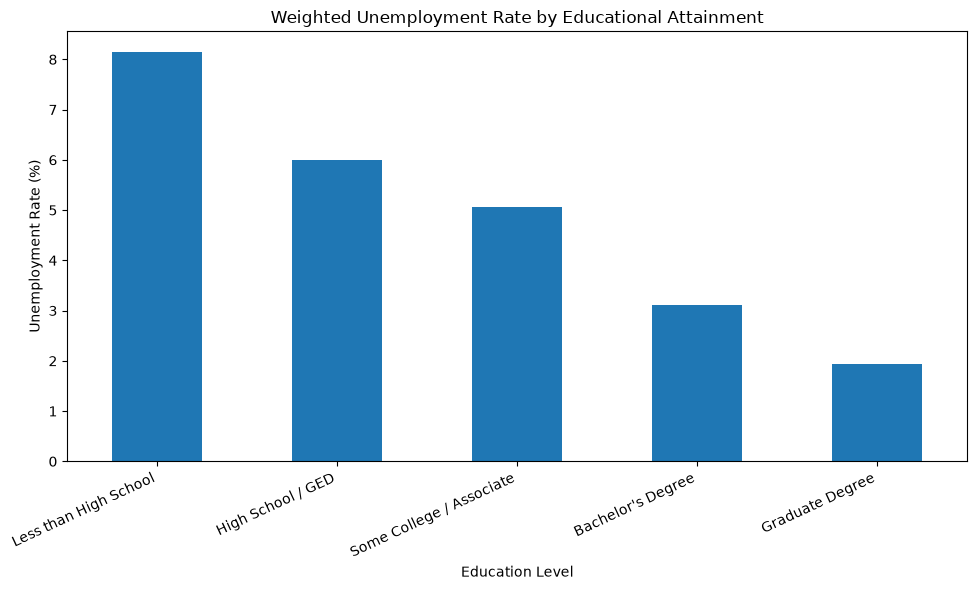

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

weighted_unemployment_percent.plot(kind="bar")

plt.title("Weighted Unemployment Rate by Educational Attainment")
plt.xlabel("Education Level")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=25, ha="right")

plt.tight_layout()

plt.savefig(
    "outputs/figure1_unemployment_by_education.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


The figure shows a clear pattern between education and unemployment. People with less than a high school education had the highest weighted unemployment rate, at about 8.15%. The rate decreased to 6.01% for people with a high school diploma or GED and 5.05% for those with some college education or an associate degree. The unemployment rate was even lower for people with a bachelor's degree, at 3.11%, and was lowest among people with a graduate degree, at 1.94%.
Overall, higher education levels are associated with lower unemployment rates in this sample. However, this is only a descriptive comparison. Other factors may also affect unemployment, so the next step is to examine whether this relationship remains after controlling for demographic characteristics.

### 3.2 Unemployment Trends by Education, 2020–2024

In [72]:
# Weighted unemployment rate by year and education

trend_df = (
    analysis_df
    .groupby(["YEAR", "EDUCATION"])[["WEIGHTED_UNEMPLOYED", "PWGTP"]]
    .sum()
    .reset_index()
)

trend_df["UNEMPLOYMENT_RATE"] = (
    trend_df["WEIGHTED_UNEMPLOYED"] / trend_df["PWGTP"] * 100
)

print(trend_df.head(10))

   YEAR                 EDUCATION  WEIGHTED_UNEMPLOYED   PWGTP  \
0  2020         Bachelor's Degree                11968  265028   
1  2020           Graduate Degree                 5144  173241   
2  2020         High School / GED                21893  293731   
3  2020     Less than High School                 4940   49927   
4  2020  Some College / Associate                19233  279859   
5  2021         Bachelor's Degree                 9641  269552   
6  2021           Graduate Degree                 3585  173889   
7  2021         High School / GED                22536  291797   
8  2021     Less than High School                 6692   57455   
9  2021  Some College / Associate                16856  270470   

   UNEMPLOYMENT_RATE  
0           4.515749  
1           2.969274  
2           7.453418  
3           9.894446  
4           6.872389  
5           3.576675  
6           2.061660  
7           7.723177  
8          11.647376  
9           6.232114  


In [47]:
trend_pivot = trend_df.pivot(
    index="YEAR",
    columns="EDUCATION",
    values="UNEMPLOYMENT_RATE"
)

trend_pivot = trend_pivot[
    [
        "Less than High School",
        "High School / GED",
        "Some College / Associate",
        "Bachelor's Degree",
        "Graduate Degree"
    ]
]

print(trend_pivot.round(2))

EDUCATION  Less than High School  High School / GED  Some College / Associate  \
YEAR                                                                            
2020                        9.89               7.45                      6.87   
2021                       11.65               7.72                      6.23   
2022                        4.70               5.06                      3.88   
2023                        6.39               5.23                      3.96   
2024                        8.07               4.51                      4.19   

EDUCATION  Bachelor's Degree  Graduate Degree  
YEAR                                           
2020                    4.52             2.97  
2021                    3.58             2.06  
2022                    2.13             1.62  
2023                    2.57             1.56  
2024                    2.78             1.58  


### Figure 2. Weighted Unemployment Rate by Education, 2020–2024

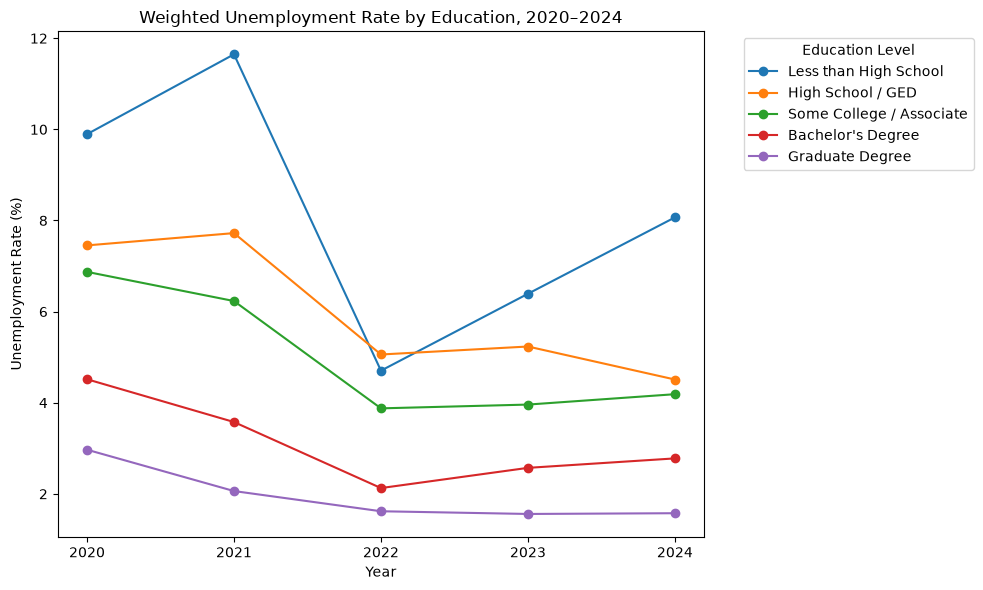

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for col in trend_pivot.columns:
    plt.plot(trend_pivot.index, trend_pivot[col], marker="o", label=col)

plt.title("Weighted Unemployment Rate by Education, 2020–2024")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(trend_pivot.index)
plt.legend(title="Education Level", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()

plt.savefig(
    "outputs/figure2_unemployment_by_education_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Figure 2 shows that unemployment rates varied over time, but the overall relationship between education and unemployment remained consistent. Adults with bachelor's and graduate degrees had relatively low unemployment rates throughout 2020–2024. In contrast, people with less than a high school education generally experienced the highest unemployment rates and the largest year-to-year fluctuations. Their unemployment rate increased from about 9.89% in 2020 to 11.65% in 2021, fell sharply to 4.70% in 2022, and then rose again to 8.07% in 2024. High school graduates and people with some college education generally remained between these two extremes. Overall, the figure suggests that higher educational attainment is associated not only with lower unemployment rates, but also with more stable unemployment outcomes over this period.

### 3.3 Sample Characteristics

#### Table 1. Sample Characteristics

In [49]:
# Weighted sample characteristics

total_n = len(analysis_df)

weighted_mean_age = (
    (analysis_df["AGEP"] * analysis_df["PWGTP"]).sum()
    / analysis_df["PWGTP"].sum()
)

weighted_female_percent = (
    analysis_df.loc[analysis_df["SEX"] == 2, "PWGTP"].sum()
    / analysis_df["PWGTP"].sum()
    * 100
)

overall_weighted_unemployment = (
    analysis_df["WEIGHTED_UNEMPLOYED"].sum()
    / analysis_df["PWGTP"].sum()
    * 100
)

weighted_education_distribution = (
    analysis_df.groupby("EDUCATION")["PWGTP"].sum()
    / analysis_df["PWGTP"].sum()
    * 100
).reindex(education_order)

In [74]:
table1 = pd.DataFrame({
    "Characteristic": [
        "Observations",
        "Weighted Mean Age",
        "Female (%)",
        "Less than High School (%)",
        "High School / GED (%)",
        "Some College / Associate (%)",
        "Bachelor's Degree (%)",
        "Graduate Degree (%)",
        "Weighted Unemployment Rate (%)"
    ],
    "Value": [
        total_n,
        round(weighted_mean_age, 2),
        round(weighted_female_percent, 2),
        round(weighted_education_distribution["Less than High School"], 2),
        round(weighted_education_distribution["High School / GED"], 2),
        round(weighted_education_distribution["Some College / Associate"], 2),
        round(weighted_education_distribution["Bachelor's Degree"], 2),
        round(weighted_education_distribution["Graduate Degree"], 2),
        round(overall_weighted_unemployment, 2)
    ]
})

table1.to_csv(
    "outputs/table1_sample_characteristics.csv",
    index=False
)

table1

,Characteristic,Value
0,Observations,249839.00
1,Weighted Mean Age,43.73
2,Female (%),47.65
3,Less than High School (%),5.17
4,High School / GED (%),27.33
5,Some College / Associate (%),25.23
6,Bachelor's Degree (%),25.40
7,Graduate Degree (%),16.87
8,Weighted Unemployment Rate (%),4.45


## 4. Logistic Regression Analysis

### 4.1 Adjusted Weighted Model

In [77]:
model2 = smf.glm(
    formula="UNEMPLOYED ~ C(EDUCATION) + AGEP + C(SEX) + C(RACE_GROUP) + C(YEAR)",
    data=analysis_df,
    family=sm.families.Binomial(),
    freq_weights=analysis_df["PWGTP"]
).fit()

print(model2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             UNEMPLOYED   No. Observations:               249839
Model:                            GLM   Df Residuals:                  5314346
Model Family:                Binomial   Df Model:                           13
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -9.2788e+05
Date:                Wed, 07 Oct 2026   Deviance:                   1.8558e+06
Time:                        13:04:59   Pearson chi2:                 5.36e+06
No. Iterations:                     7   Pseudo R-squ. (CS):             0.2745
Covariance Type:            nonrobust                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

### 4.2 Model Results

In [79]:
import numpy as np

odds_ratios = np.exp(model2.params)
conf_int = np.exp(model2.conf_int())

table2 = pd.DataFrame({
    "Odds Ratio": odds_ratios,
    "CI Lower": conf_int[0],
    "CI Upper": conf_int[1],
    "P-value": model2.pvalues
})

#### Table 2. Adjusted Weighted Logistic Regression Results

In [78]:
education_rows = [
    "C(EDUCATION)[T.Graduate Degree]",
    "C(EDUCATION)[T.High School / GED]",
    "C(EDUCATION)[T.Less than High School]",
    "C(EDUCATION)[T.Some College / Associate]"
]

table2_report = table2.loc[education_rows].copy()

table2_report.index = [
    "Graduate Degree",
    "High School / GED",
    "Less than High School",
    "Some College / Associate"
]

table2_report.to_csv(
    "outputs/table2_logistic_regression_results.csv",
    index=True
)

table2_report.round(3)

,Odds Ratio,CI Lower,CI Upper,P-value
Graduate Degree,0.636,0.624,0.647,0.0
High School / GED,1.958,1.935,1.982,0.0
Less than High School,2.565,2.521,2.610,0.0
Some College / Associate,1.585,1.566,1.605,0.0


### 4.3 Adjusted Predicted Probabilities

In [57]:
# Calculate adjusted predicted probability for each education group

predicted_probabilities = []

for education in education_order:
    
    temp_df = analysis_df.copy()
    temp_df["EDUCATION"] = education
    
    temp_df["PREDICTED_PROBABILITY"] = model2.predict(temp_df)
    
    weighted_probability = (
        (temp_df["PREDICTED_PROBABILITY"] * temp_df["PWGTP"]).sum()
        / temp_df["PWGTP"].sum()
        * 100
    )
    
    predicted_probabilities.append(weighted_probability)

predicted_df = pd.DataFrame({
    "Education": education_order,
    "Predicted Unemployment Probability (%)": predicted_probabilities
})

predicted_df

,Education,Predicted Unemployment Probability (%)
0,Less than High School,7.670472
1,High School / GED,5.982530
2,Some College / Associate,4.909337
3,Bachelor's Degree,3.164821
4,Graduate Degree,2.039528


#### Figure 3. Adjusted Predicted Probability of Unemployment by Education

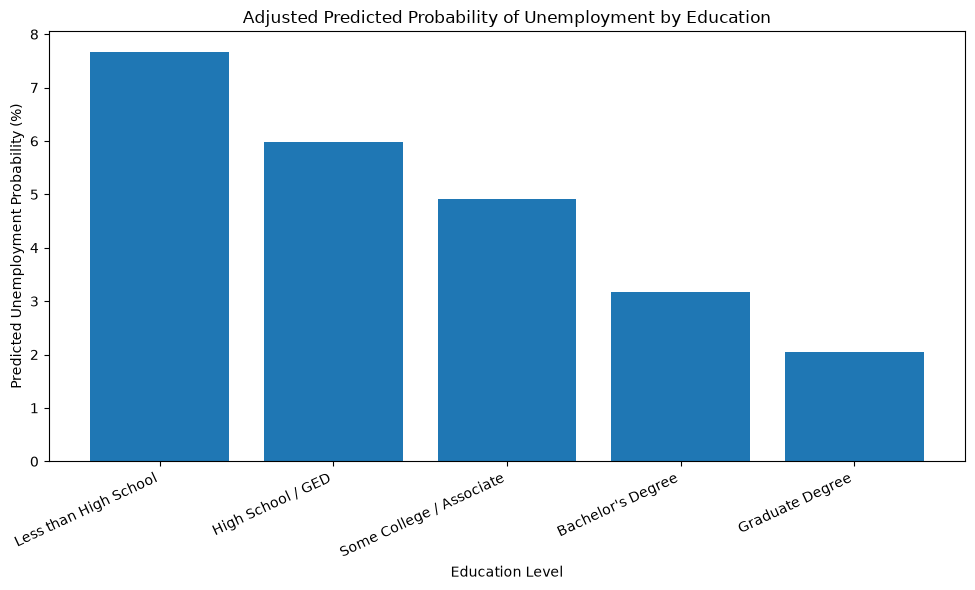

In [76]:
plt.figure(figsize=(10, 6))

plt.bar(
    predicted_df["Education"],
    predicted_df["Predicted Unemployment Probability (%)"]
)

plt.title("Adjusted Predicted Probability of Unemployment by Education")
plt.xlabel("Education Level")
plt.ylabel("Predicted Unemployment Probability (%)")

plt.xticks(rotation=25, ha="right")

plt.tight_layout()

plt.savefig(
    "outputs/figure3_predicted_probability_by_education.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Figure 3 shows that the education gradient remains after controlling for age, sex, race, and year. The adjusted predicted probability of unemployment was highest for individuals with less than a high school education, at about 7.67%. The probability declined to 5.98% for high school or GED holders, 4.91% for those with some college education or an associate degree, and 3.16% for bachelor's degree holders. Graduate degree holders had the lowest adjusted probability, at about 2.04%. Overall, the model suggests that higher educational attainment is associated with a lower probability of unemployment even after accounting for demographic characteristics and year.

## 5. Model Evaluation and Validation

### 5.1 Train–Test Split

In [60]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    analysis_df,
    test_size=0.2,
    random_state=42,
    stratify=analysis_df["UNEMPLOYED"]
)

print("Training observations:", len(train_df))
print("Testing observations:", len(test_df))

print("\nTraining unemployment rate:")
print(train_df["UNEMPLOYED"].mean())

print("\nTesting unemployment rate:")
print(test_df["UNEMPLOYED"].mean())

Training observations: 199871
Testing observations: 49968

Training unemployment rate:
0.0377393418755097

Testing unemployment rate:
0.037744156260006406


### 5.2 Model Fitting on the Training Set

In [61]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

evaluation_model = smf.glm(
    formula="UNEMPLOYED ~ C(EDUCATION) + AGEP + C(SEX) + C(RACE_GROUP) + C(YEAR)",
    data=train_df,
    family=sm.families.Binomial(),
    freq_weights=train_df["PWGTP"]
).fit()

print(evaluation_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             UNEMPLOYED   No. Observations:               199871
Model:                            GLM   Df Residuals:                  4260301
Model Family:                Binomial   Df Model:                           13
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -7.4037e+05
Date:                Wed, 07 Oct 2026   Deviance:                   1.4807e+06
Time:                        11:49:24   Pearson chi2:                 4.29e+06
No. Iterations:                     7   Pseudo R-squ. (CS):             0.2618
Covariance Type:            nonrobust                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

### 5.3 Test-Set Predictions

In [62]:
# Predict unemployment probability on the test set
test_df = test_df.copy()

test_df["PREDICTED_PROBABILITY"] = evaluation_model.predict(test_df)

# Convert probability into predicted class
test_df["PREDICTED_CLASS"] = (
    test_df["PREDICTED_PROBABILITY"] >= 0.5
).astype(int)

test_df[
    ["UNEMPLOYED", "PREDICTED_PROBABILITY", "PREDICTED_CLASS"]
].head()

,UNEMPLOYED,PREDICTED_PROBABILITY,PREDICTED_CLASS
43025,0,0.068252,0
217445,0,0.037671,0
236145,0,0.050470,0
56612,0,0.032896,0
278797,0,0.042369,0


### 5.4 Model Performance

In [65]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)

accuracy = accuracy_score(
    test_df["UNEMPLOYED"],
    test_df["PREDICTED_CLASS"]
)

precision = precision_score(
    test_df["UNEMPLOYED"],
    test_df["PREDICTED_CLASS"],
    zero_division=0
)

recall = recall_score(
    test_df["UNEMPLOYED"],
    test_df["PREDICTED_CLASS"],
    zero_division=0
)

roc_auc = roc_auc_score(
    test_df["UNEMPLOYED"],
    test_df["PREDICTED_PROBABILITY"]
)

cm = confusion_matrix(
    test_df["UNEMPLOYED"],
    test_df["PREDICTED_CLASS"]
)

print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("ROC-AUC:", round(roc_auc, 3))

print("\nConfusion Matrix:")
print(cm)

Accuracy: 0.962
Precision: 0.0
Recall: 0.0
ROC-AUC: 0.659

Confusion Matrix:
[[48082     0]
 [ 1886     0]]


The model achieved an accuracy of 96.2%, but this high accuracy was largely driven by the low unemployment rate in the test sample. At the standard 0.5 classification threshold, the model classified all observations as employed, resulting in precision and recall of zero. However, the ROC-AUC was 0.659, indicating modest ability to distinguish between individuals with higher and lower unemployment risk. Therefore, the model is more useful for examining associations and relative unemployment risk than for predicting individual unemployment outcomes.